#**Assignment - Week 4**

Iris Wu

In [83]:
#Load libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler


In [84]:
#Load the dataset
df = pd.read_csv("https://raw.githubusercontent.com/Reben80/Data201/refs/heads/main/Dataset/housing.csv")
df.head()

,listing_id,price,size,bedrooms,neighborhood,type
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily


##**Step 0 - Create a Binary Outcome**

In [87]:
df_clean = df.dropna(subset = ["size", "bedrooms", "price"]).copy()
df_clean["high_price"] = (df["price"] > np.median(df["price"]))
#kept getting an error when trying to perform logistic regression, so converted high_price column to integers
df_clean["high_price"] = df_clean["high_price"].astype(int)
df_clean.head()

,listing_id,price,size,bedrooms,neighborhood,type,high_price
0,100001,145143.0,1280.741760,1.0,Suburb,Townhouse,0
1,100002,152251.0,1406.283113,2.0,Uptown,SingleFamily,0
2,100003,148251.0,4146.825713,6.0,Suburb,MultiFamily,0
3,100004,177711.0,3946.599818,6.0,Suburb,SingleFamily,0
4,100005,155269.0,1243.751760,1.0,Downtown,MultiFamily,0


##**Data Exploration**



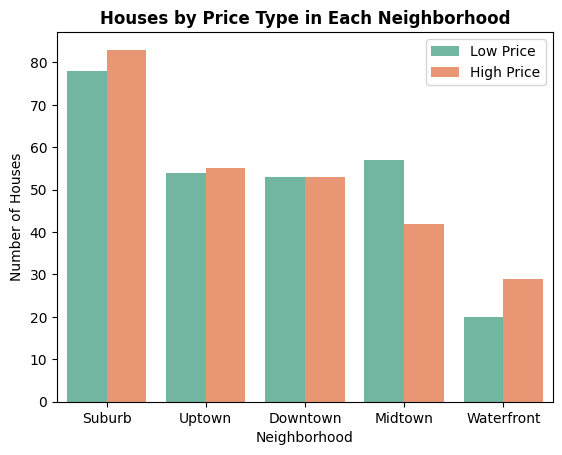

In [88]:
#first exploratory plot
sns.countplot(data = df_clean, x = "neighborhood", hue = "high_price", palette = "Set2")
plt.title("Houses by Price Type in Each Neighborhood", fontweight = "bold")
plt.legend(labels = ["Low Price", "High Price"])
plt.xlabel("Neighborhood")
plt.ylabel("Number of Houses")
plt.show()


My first plot shows how many high and low-price homes are in each neighborhood. Midtown is the only neighborhood where there are more low-price than high-price homes.

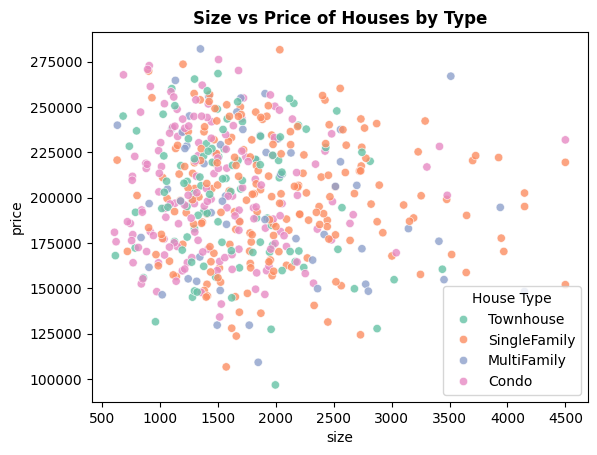

In [89]:
#second exploratory plot
sns.scatterplot(data = df_clean, x = "size", y = "price", hue = "type", alpha = 0.8, palette = "Set2")
plt.title("Size vs Price of Houses by Type", fontweight = "bold")
plt.legend(title = "House Type")
plt.show()

There is no linear correlation between housing size and price, which is surprising, since the common assumption is that prices increase with size. Although the plot also shows types of houses, it is difficult to accurately gauge which type corresponds with higher prices.

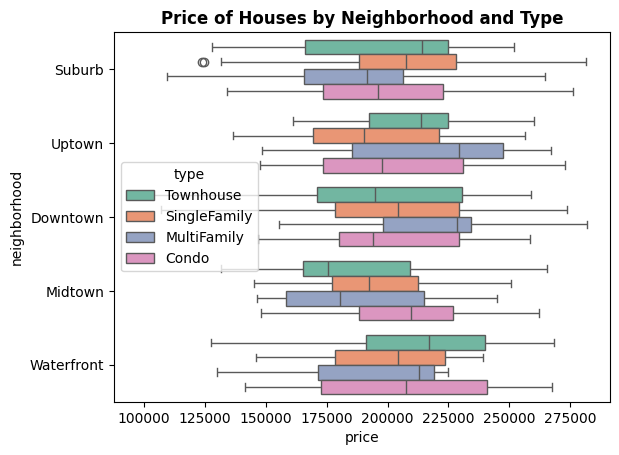

In [91]:
#third exploratory plot
sns.boxplot(data = df_clean, x = "price", y = "neighborhood", hue = "type", palette = "Set2")
plt.title("Price of Houses by Neighborhood and Type", fontweight = "bold")
plt.show()



My third plot shows the prices of houses in each neighborhood, organized by type of house. The median price of a type of house varies depending on its neighborhood. For example, median prices of multi-family homes in Uptown are more expensive than those in Midtown or the Suburb. Overall median home prices in Midtown are the lowest among all neighborhoods.

##**Part A - Logistic Regression for Inference**

In [92]:
model_housing = smf.logit("high_price ~ size + bedrooms + C(neighborhood) + C(type)", data=df_clean).fit()
model_housing.summary()


Optimization terminated successfully.
         Current function value: 0.683349
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             high_price   No. Observations:                  524
Model:                          Logit   Df Residuals:                      514
Method:                           MLE   Df Model:                            9
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                 0.01414
Time:                        03:12:47   Log-Likelihood:                -358.07
converged:                       True   LL-Null:                       -363.21
Covariance Type:            nonrobust   LLR p-value:                    0.3292
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.2590      0.309      0.837      0.403      -0.347       0.866
C(neighborhood)[T.Midtown]       -0.2657      0.286     -0.931      0.352      -0.825       0.294
C(neighborhood)[T.Suburb]         0.1402      0.258      0.544      0.587      -0.365       0.645
C(neighborhood)[T.Uptown]         0.0552      0.277      0.199      0.842      -0.488       0.599
C(neighborhood)[T.Waterfront]     0.4327      0.356      1.217      0.224      -0.264       1.130
C(type)[T.MultiFamily]            0.0079      0.319      0.025      0.980      -0.617       0.633
C(type)[T.SingleFamily]           0.1169      0.225      0.520      0.603      -0.324       0.557
C(type)[T.Townhouse]              0.3204      0.257      1.245      0.213      -0.184       0.825
size                             -0.0005      0.000     -2.090      0.037      -0.001   -3.28e-05
bedrooms                          0.2308      0.134      1.721      0.085      -0.032       0.494
=================================================================================================
"""

In [93]:
#calculate the odds ratio
model_odds = pd.DataFrame(np.exp(model_housing.params), columns = ["OR"])
model_odds[["2.5%", "97.5%"]] = np.exp(model_housing.conf_int())
print(model_odds)


                                     OR      2.5%     97.5%
Intercept                      1.295677  0.706481  2.376257
C(neighborhood)[T.Midtown]     0.766643  0.438064  1.341679
C(neighborhood)[T.Suburb]      1.150462  0.694104  1.906866
C(neighborhood)[T.Uptown]      1.056716  0.613687  1.819575
C(neighborhood)[T.Waterfront]  1.541338  0.767754  3.094379
C(type)[T.MultiFamily]         1.007977  0.539442  1.883463
C(type)[T.SingleFamily]        1.123955  0.723524  1.746004
C(type)[T.Townhouse]           1.377664  0.831847  2.281619
size                           0.999475  0.998983  0.999967
bedrooms                       1.259642  0.968435  1.638414


The only statistically significant predictor is size because its p-value of 0.037 is less than 0.05. Moreover, the confidence interval for odds ratio of size stays below 1, while all the other intervals cross 1. For every one-square-foot increase in the size of a home, the odds of it being a "high price" home decreases by around 0.05%. The small odds ratio aligns with the fact that one-unit increases in size are negligible. 500 square feet is not significantly different from 501 square feet. However, it is counterintuitive that a larger house has lower odds of being expensive.

The Waterfront neighborhood has the largest odds ratio of 1.54, suggesting that the odds of a Waterfront home being "high price" increases by 54%. However, this variable is not statistically significant, as its confidence interval is too wide and its p-value is greater than 0.05. The model does not provide enough evidence to conclude whether a Waterfront location independently influences home price.



##**Part B - Interpretation**



For every additional bedroom, the odds of a house being "high price" increases by around 26%. However, this estimate lies within a range that spans from a 3.1% decrease in odds to a 64% increase, which  includes the possibility of no effect (0%). As a result, it is unclear whether the number of bedrooms has an actual influence on the price of a home.

##**Part C - Prediction Workflow**

**1. Train/Test Split**

In [95]:

#change neighborhood and type into numerical variables
X = df_numerical = pd.get_dummies(df_clean, columns = ["neighborhood", "type"], drop_first = True)


#assign X and y
X = df_numerical.drop(["price", "high_price", "listing_id"], axis = 1)
y = df_numerical["high_price"]


**2. Fit Logistic Regression**


In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

**3. Evaluate the model**

In [97]:
#get the model's predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

#compare the model with the actual data
df_compare = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(df_compare.head())

#calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy score: {accuracy}")

#calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print(f"roc-auc: {roc_auc}")



     Actual  Predicted
583       1          0
17        0          1
526       1          1
154       0          1
457       1          0
accuracy score: 0.4380952380952381
roc-auc: 0.418731778425656


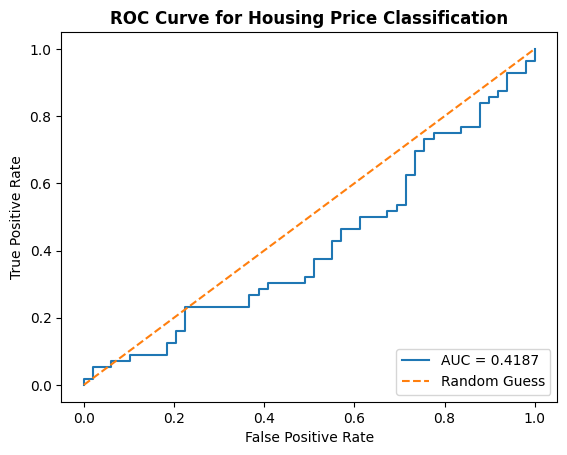

In [98]:
#plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label = f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], label = "Random Guess", linestyle = "--")
plt.title("ROC Curve for Housing Price Classification", fontweight = "bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc = "lower right")
plt.show()

The ROC curve is below the random guess classifier, which indicates the model is very weak at predicting high price.

##**Part D: Model Understanding**



1. The ROC-AUC score reveals more details about the accuracy of the model, since it reports how confident the model is about its accurate predictions. If Model 1 and Model 2 both have 95% accuracy, but Model 1 is only 60% confident and Model 2 is 85% confident, then Model 2 is more decisive and therefore more useful.

2. For policy analysis, I would use statsmodels because it reports p-values, coefficients, and standard errors, which determine the nature and stastitical significance of relationships between different variables. These relationships provide insights into the effects of the policy being studied. For prediction tasks, I would use scikit-learn because it reveals the accuracy and probabilities of a model's predictions.

